In [1]:
import os
import glob
import os
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from tqdm import tqdm
import time
from scipy.spatial.distance import cdist
import scipy
from scanpy.tools._utils import get_init_pos_from_paga 

import rmm
import cupy
import cudf
import cupy as cp
# import cvxpy as cpv
from cuml.metrics import pairwise_distances
from cuml.metrics import nan_euclidean_distances
from rmm.allocators.cupy import rmm_cupy_allocator
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

# Load in data

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/bone_marrow_processed.h5ad"

adata = sc.read_h5ad(fpath)
adata

CPU times: user 275 ms, sys: 716 ms, total: 991 ms
Wall time: 3.19 s


AnnData object with n_obs × n_vars = 5608 × 22954
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'leiden', 'bm_cluster', 'CD34_avg', 'CD164_avg', 'PROM1_avg', 'CD48_avg', 'FLT3_avg', 'MPO_avg', 'IRF8_avg', 'CD79A_avg', 'GATA1_avg', 'CD34pos_CD38neg_B0251_HTO_1', 'CD34pos_CD38pos_B0252_HTO_2', 'HTO_pred', 'HTO_pred_label', 'cluster_preds', 'CD164_mean', 'CD34_mean', 'CD38_mean', 'THY1_mean', 'PTPRC_mean', 'MME_mean', 'CD7_mean', 'FLT3_mean', 'PLEK_mean', 'BST2_mean', 'CD37_mean', 'KIT_mean', 'ICAM3_mean', 'CD44_mean', 'EVI2B_mean', 'CD63_mean', 'ITGA2B_mean', 'CSF2RB_mean', 'PROM1_mean', 'ATP1B3_mean',

In [3]:
print(adata.obs['bm_cluster'].value_counts())
print(adata.obs['cell_labels'].value_counts())

bm_cluster
B1    2225
B5    1546
B2     523
B7     505
B4     453
B3     304
B6      52
Name: count, dtype: int64
cell_labels
MPP        2225
HSC        1546
LMPP        523
CLP         505
MEG/ERY     453
CMP         304
NA           52
Name: count, dtype: int64


In [5]:
cluster_map = {
    'MPP': ['B1'], # multipotent progenitor
    'HSC': ['B5'], # hsc
    'LMPP': ['B2'], # lymphoid-primed multipotent progenitor
    'CLP': ['B7'], # common lypmhoid progenitor
    'MEP': ['B4'], # myeloid-erythroid progenitor 
    'CMP': ['B3'], # common myeloid progenitor
    'GMP': ['B6'], # granulocyte-monocyte progenitor
}

# Invert the mapping: from old -> new
reverse_map = {old: new for new, olds in cluster_map.items() for old in olds}


adata.obs['bm_cluster'] = adata.obs['bm_cluster'].astype(str)

# create new grouping
adata.obs['label'] = adata.obs['bm_cluster'].map(reverse_map)
adata.obs['label'] = adata.obs['label'].astype('category')

adata.obs['bm_cluster'] = adata.obs['bm_cluster'].astype('category')

adata.obs['label'].value_counts()

label
MPP     2225
HSC     1546
LMPP     523
CLP      505
MEP      453
CMP      304
GMP       52
Name: count, dtype: int64

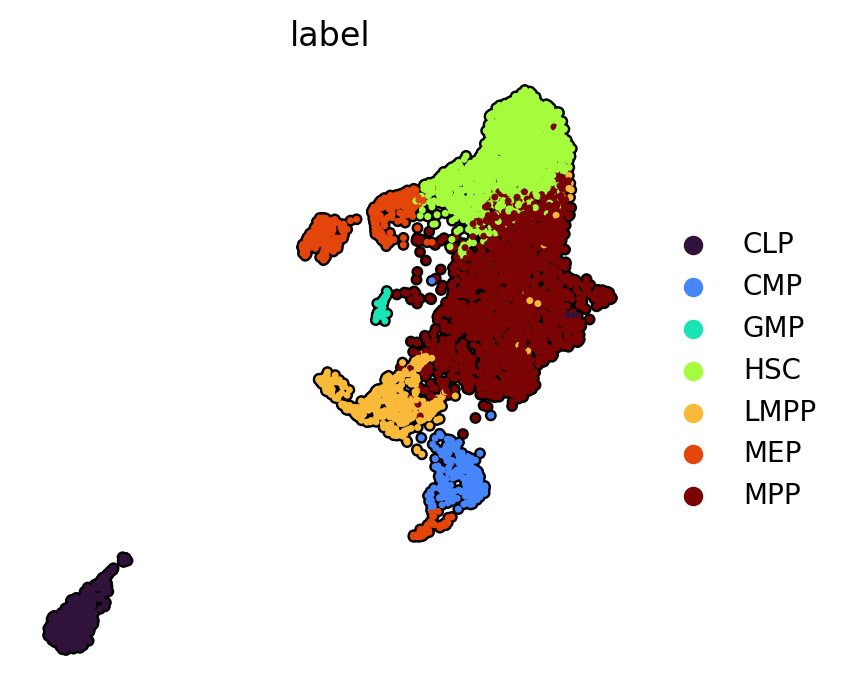

In [6]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color='label',
    palette='turbo',
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

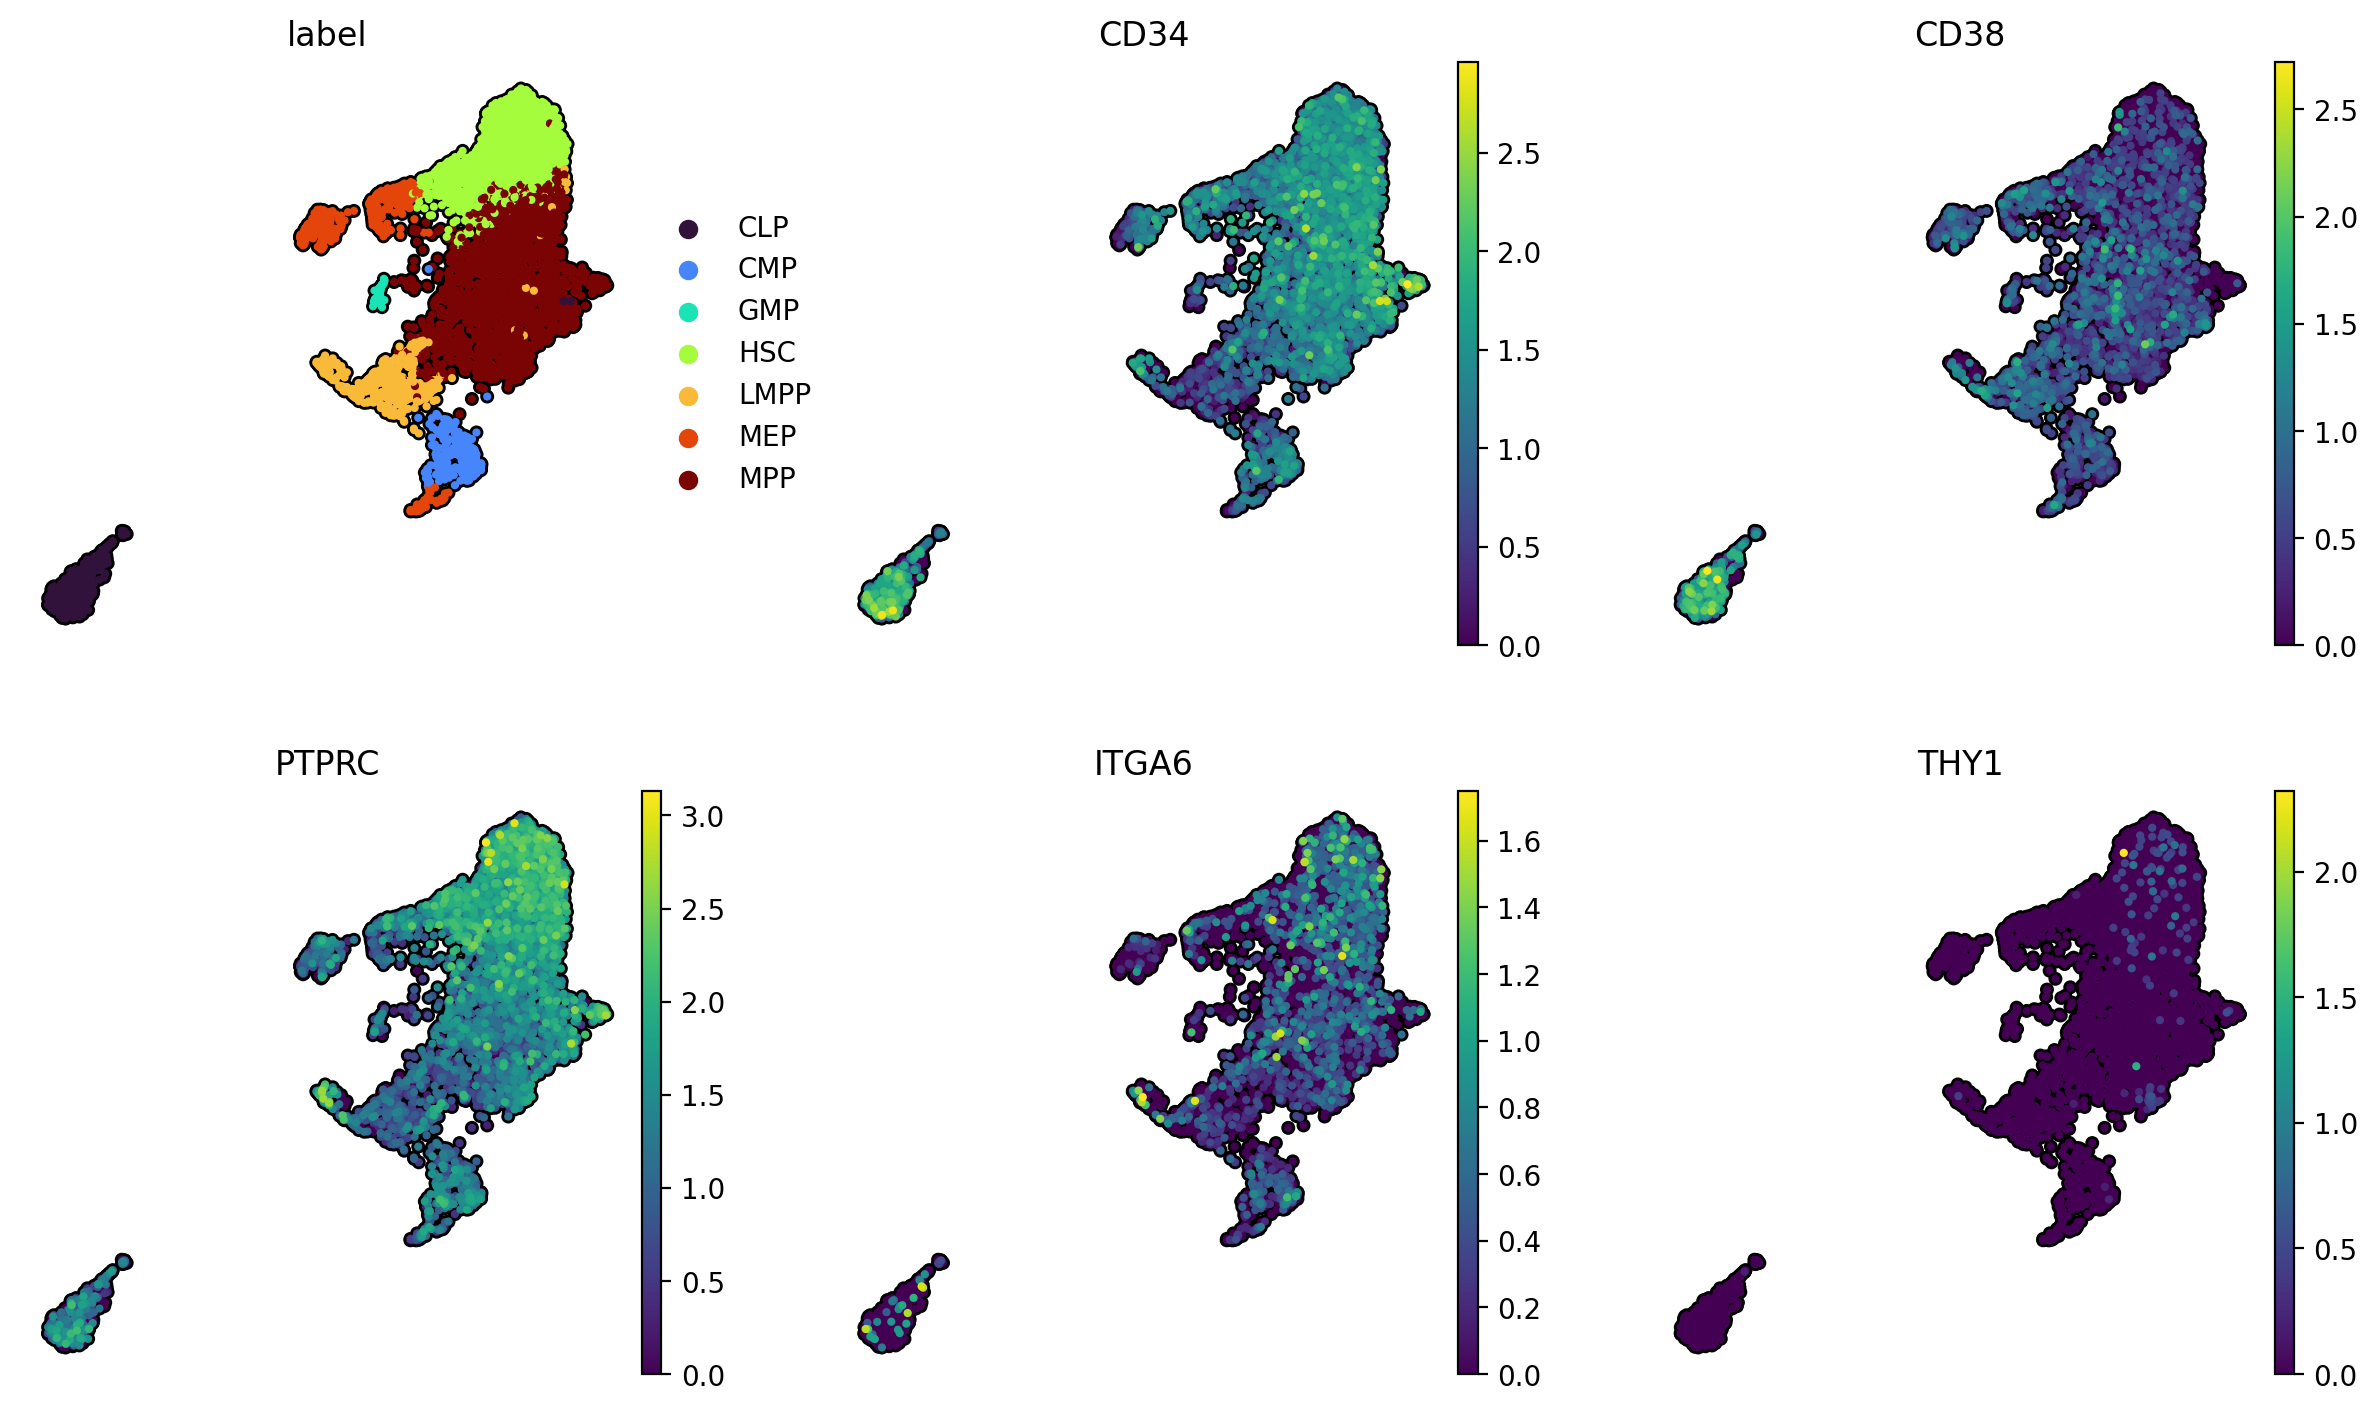

In [10]:
standard_genes = [
    'CD34', 'CD38', 'PTPRC', 'ITGA6', 'THY1',
]

genes_to_plot = [g for g in standard_genes if g in adata.var_names]

sc.pl.umap(
    adata,
    color=['label'] + genes_to_plot,
    size=35,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
)

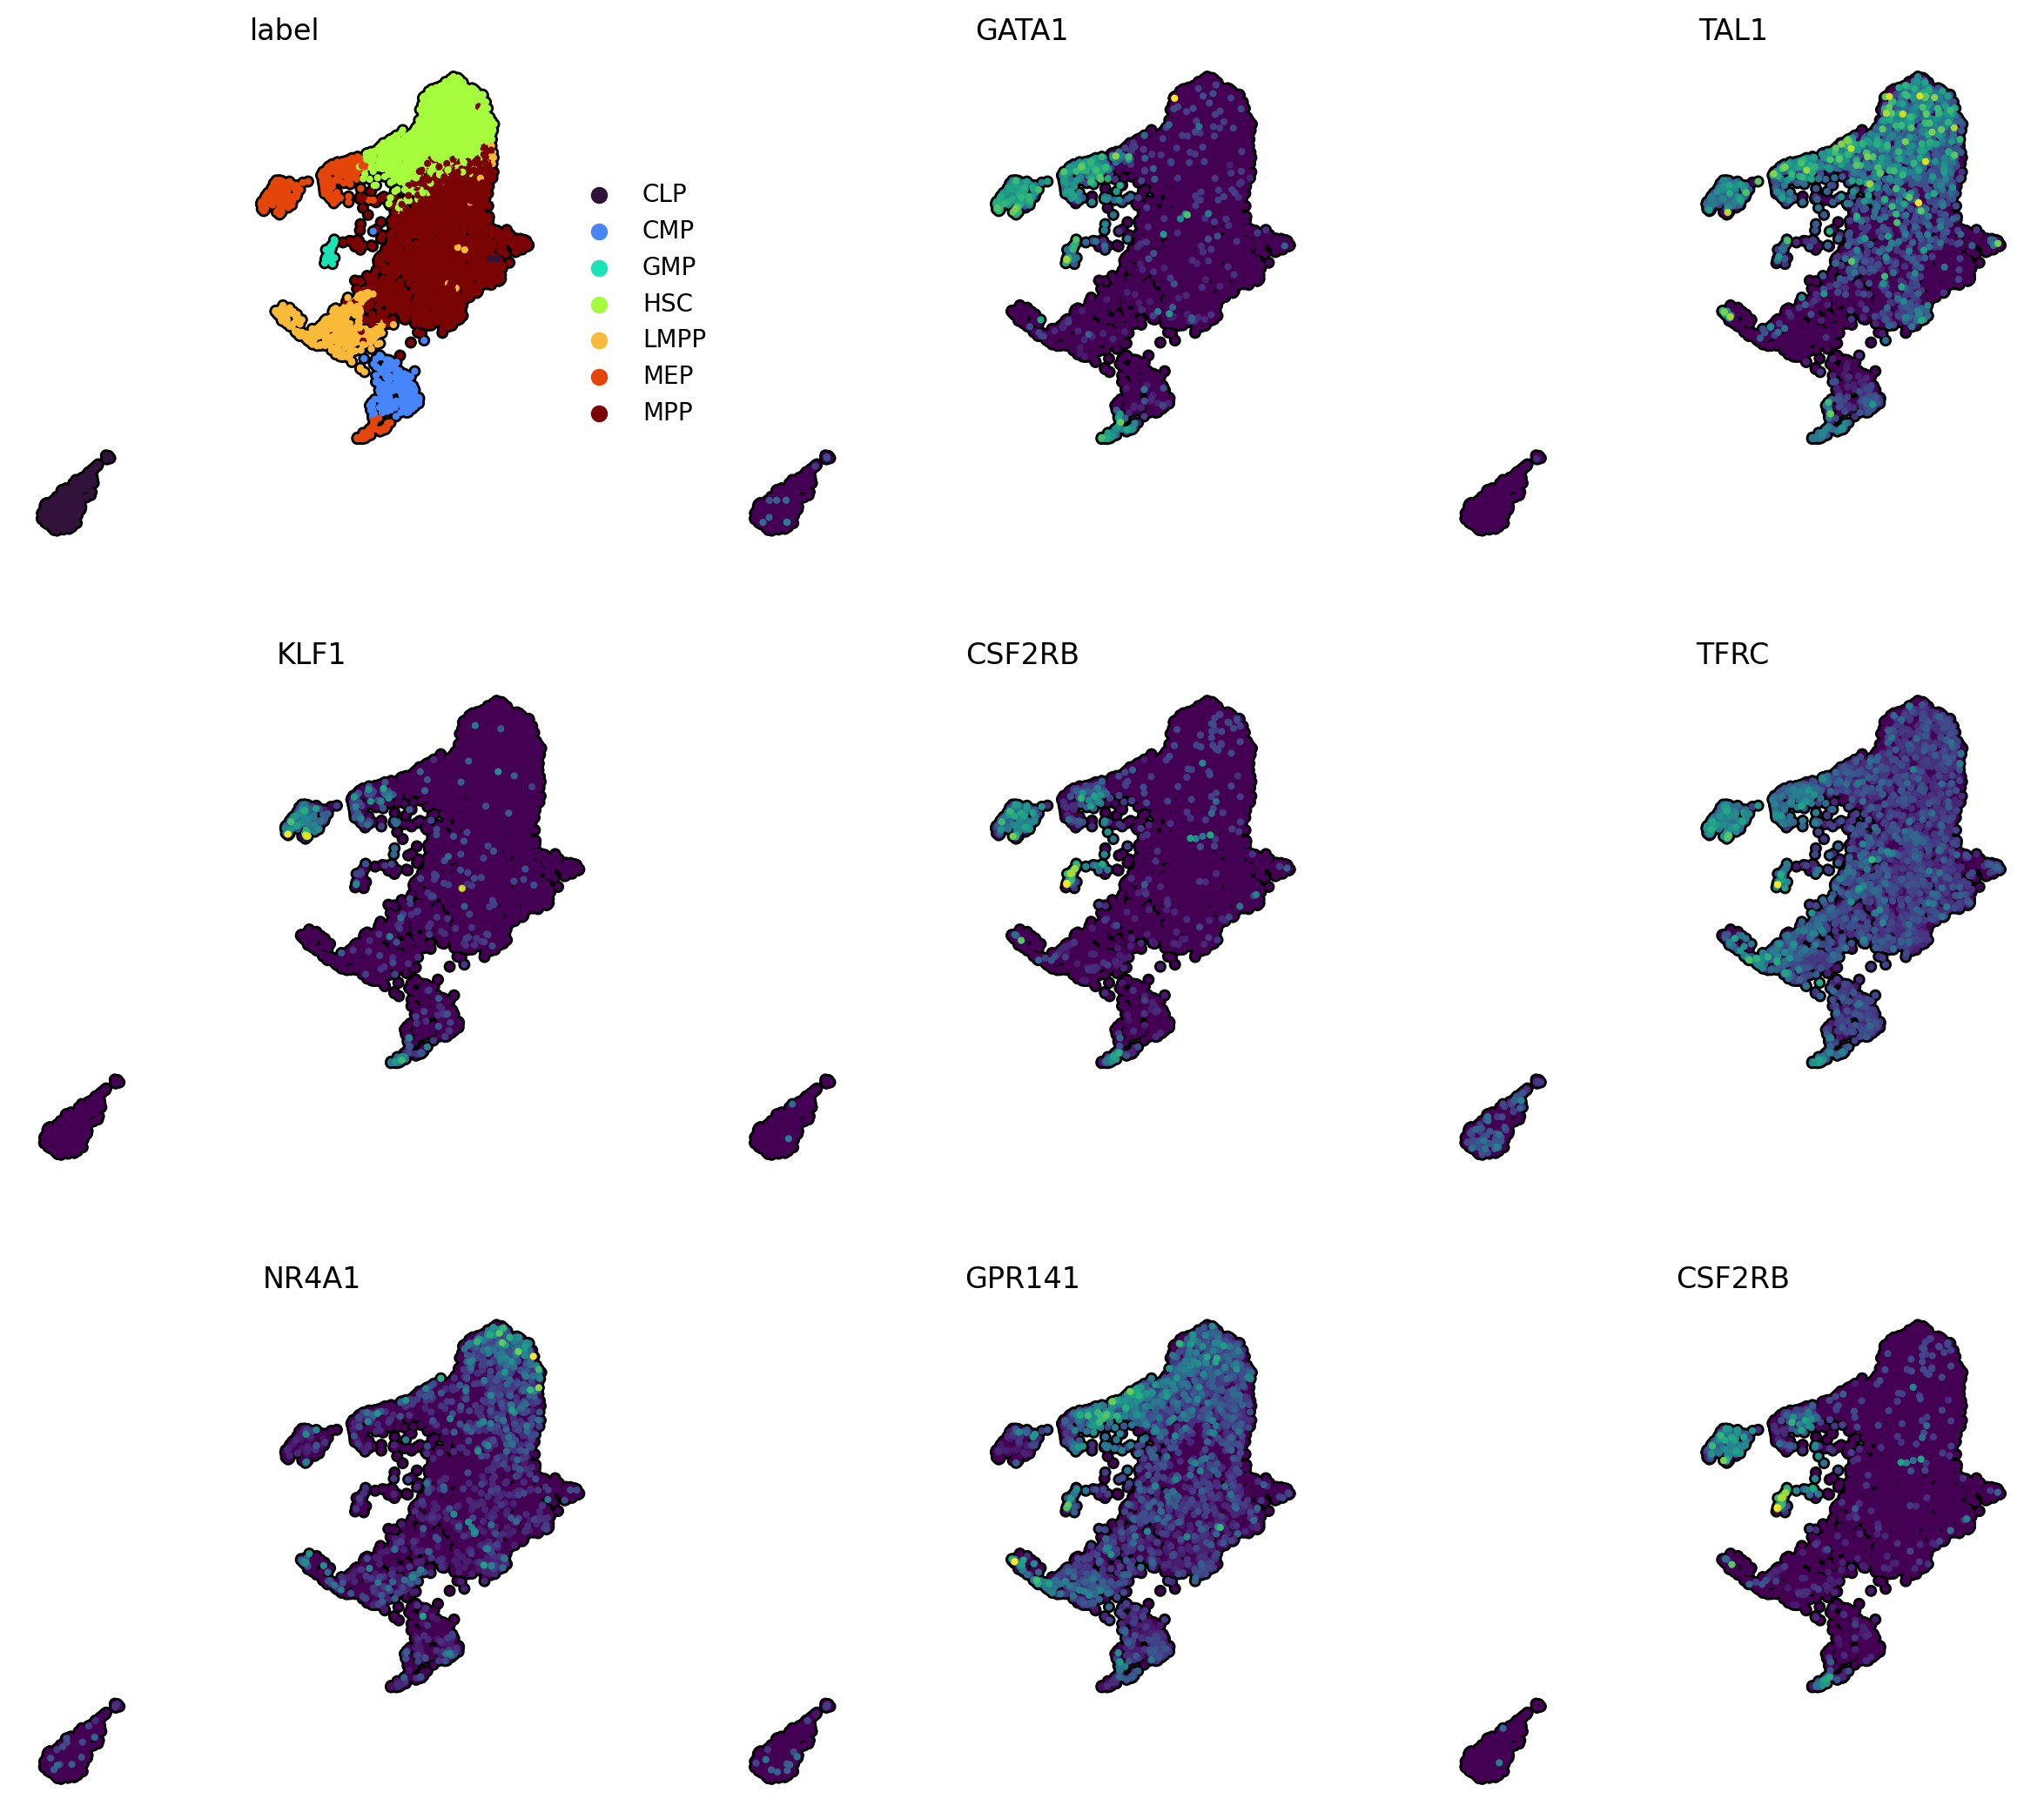

In [29]:
# MEPs
standard_genes = [
    'GATA1', # +
    'TAL1', 
    'KLF1',
    'CSF2RB',
    'TFRC', # CD71 +
    # 'ENG', # CD105 +
    'NR4A1',
    # 'LBH',
    'GPR141',
    'CSF2RB',
]

genes_to_plot = [g for g in standard_genes if g in adata.var_names]

sc.pl.umap(
    adata,
    color=['label'] + genes_to_plot,
    size=35,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    colorbar_loc=None,
    outline_color=('k', 'k'),
    frameon=False,
)

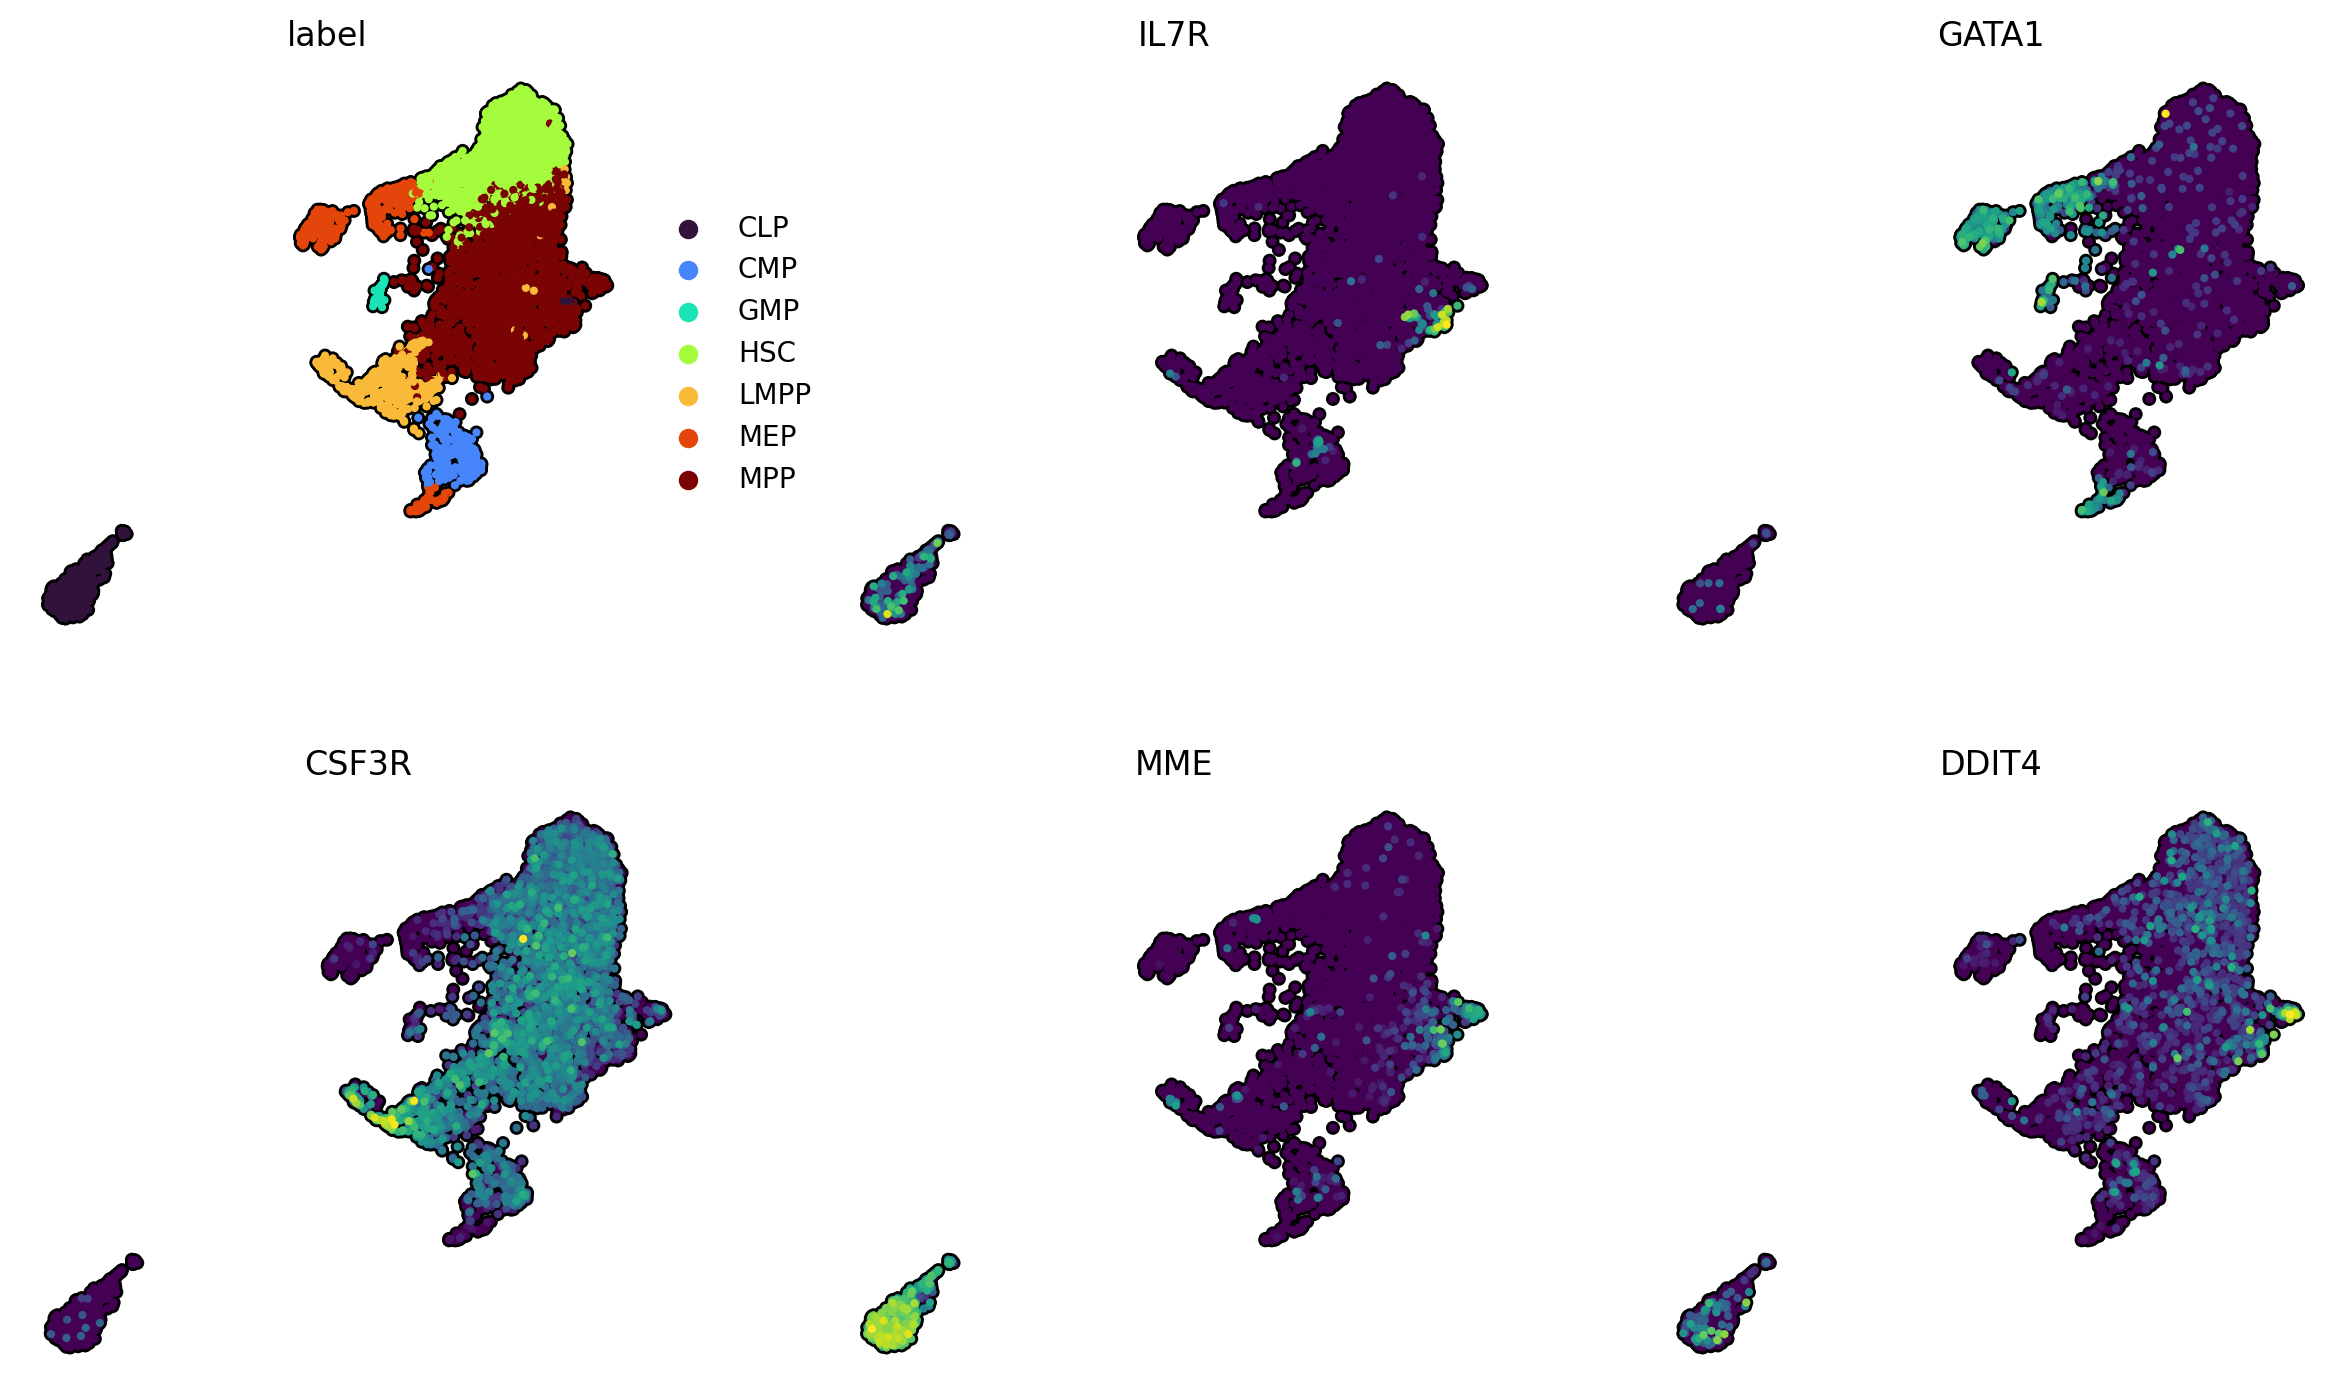

In [22]:
# CLPs
standard_genes = [
    'IL7R', # + CD127
    'GATA1', # -
    'CSF3R', # -
    'MME', # +
    'DDIT4',
    'CD24',
    'CD19',
]

genes_to_plot = [g for g in standard_genes if g in adata.var_names]

sc.pl.umap(
    adata,
    color=['label'] + genes_to_plot,
    size=35,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    colorbar_loc=None,
    outline_color=('k', 'k'),
    frameon=False,
)

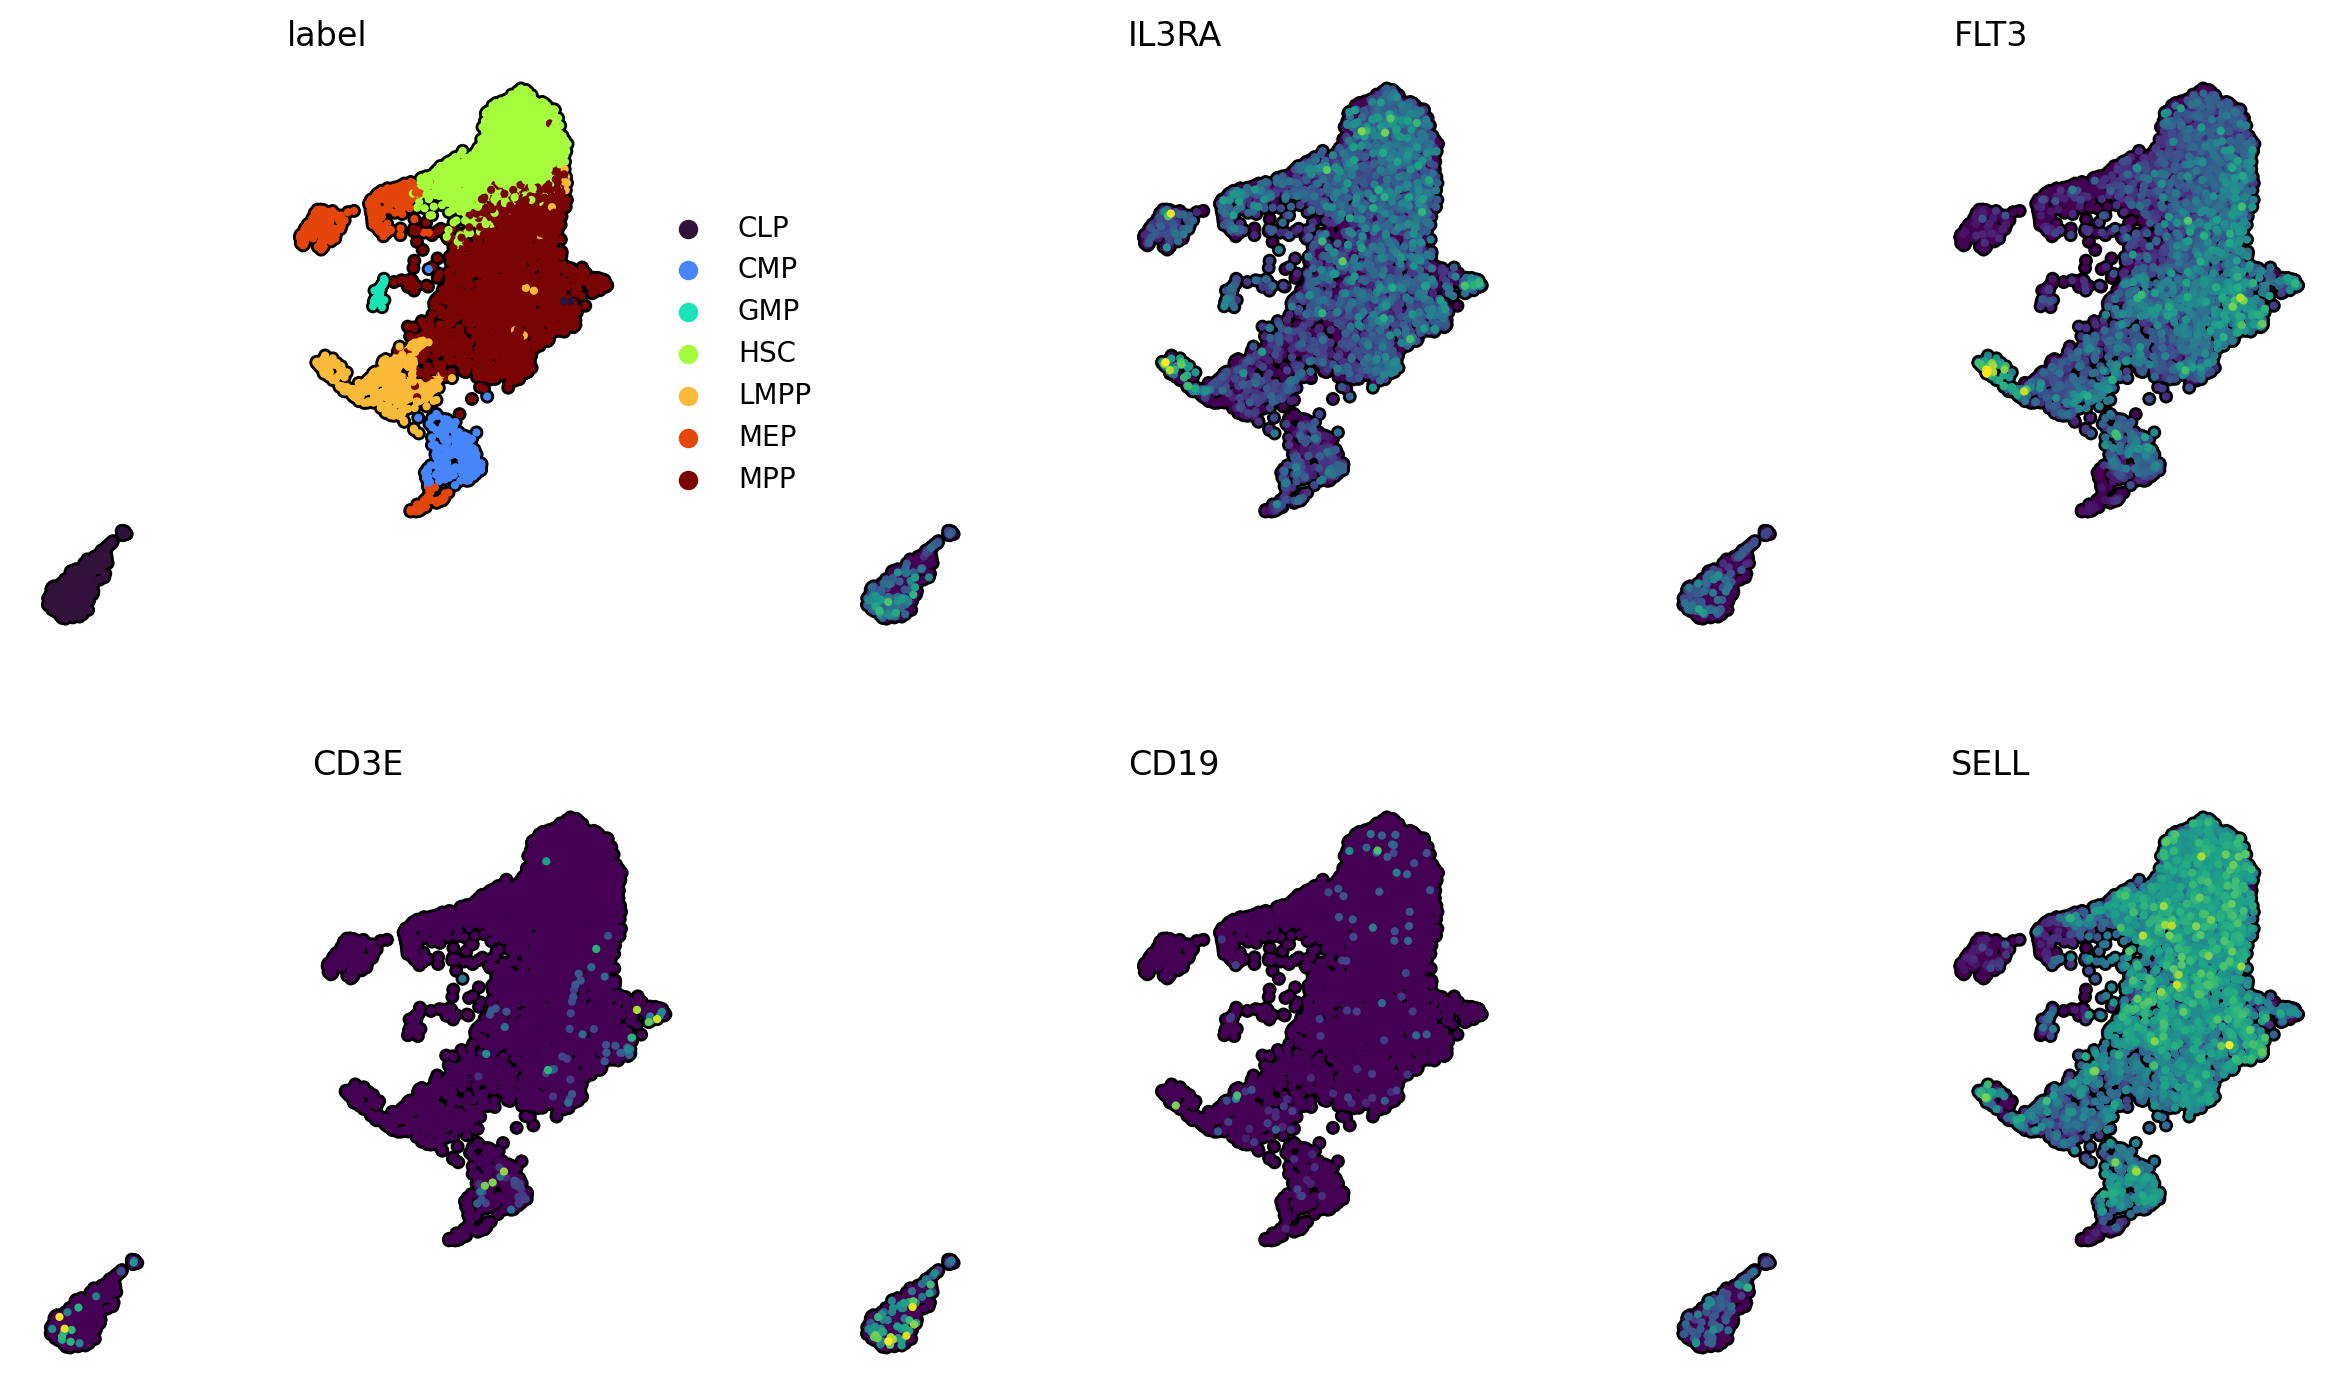

In [26]:
# CMPs
standard_genes = [
    'IL3RA', # + CD123 
    'FLT3', # +
    'CD3E', # -
    'CD3G', # -
    'CD19', # -
    'SELL', # + ?
]

genes_to_plot = [g for g in standard_genes if g in adata.var_names]

sc.pl.umap(
    adata,
    color=['label'] + genes_to_plot,
    size=35,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    colorbar_loc=None,
    outline_color=('k', 'k'),
    frameon=False,
)

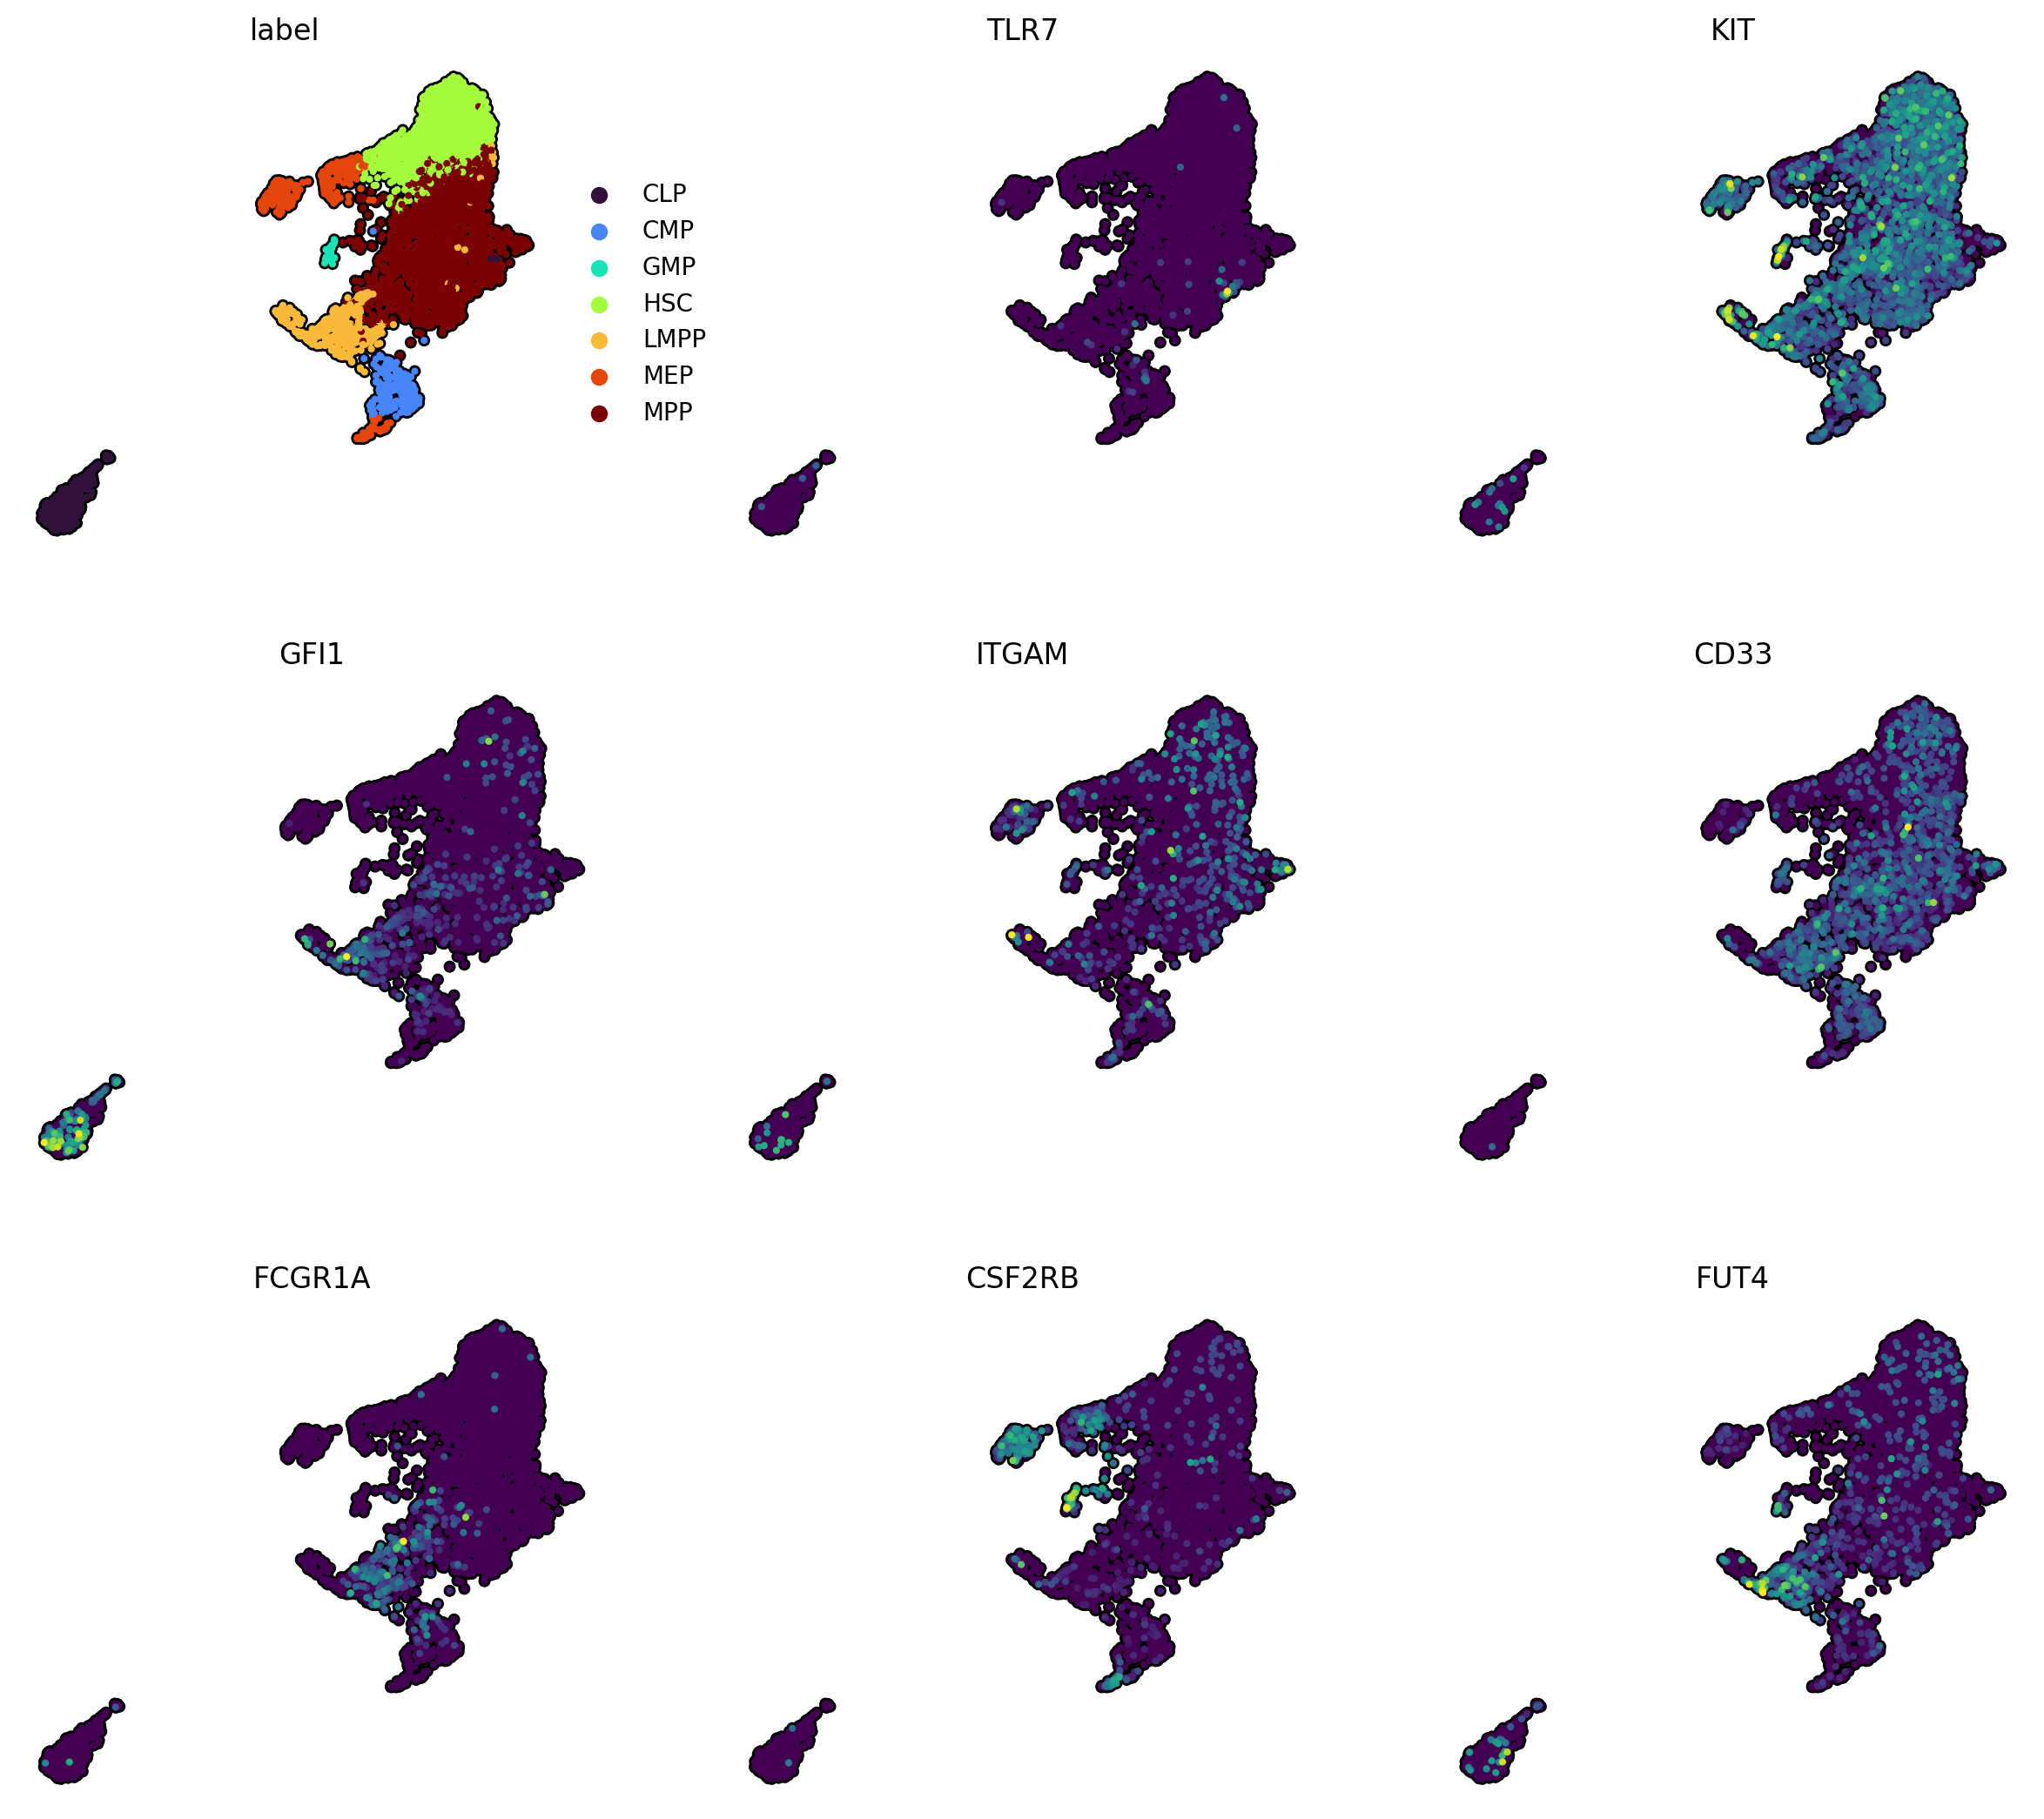

In [30]:
# GMPs
standard_genes = [
    'TLR7', # + ?
    'KIT', # + CD117
    'GFI1',
    'ITGAM', # CD11b
    'CD33',
    'FCGR1A', # CD64
    'CSF2RB',
    'FUT4',
]

genes_to_plot = [g for g in standard_genes if g in adata.var_names]

sc.pl.umap(
    adata,
    color=['label'] + genes_to_plot,
    size=35,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    colorbar_loc=None,
    outline_color=('k', 'k'),
    frameon=False,
)

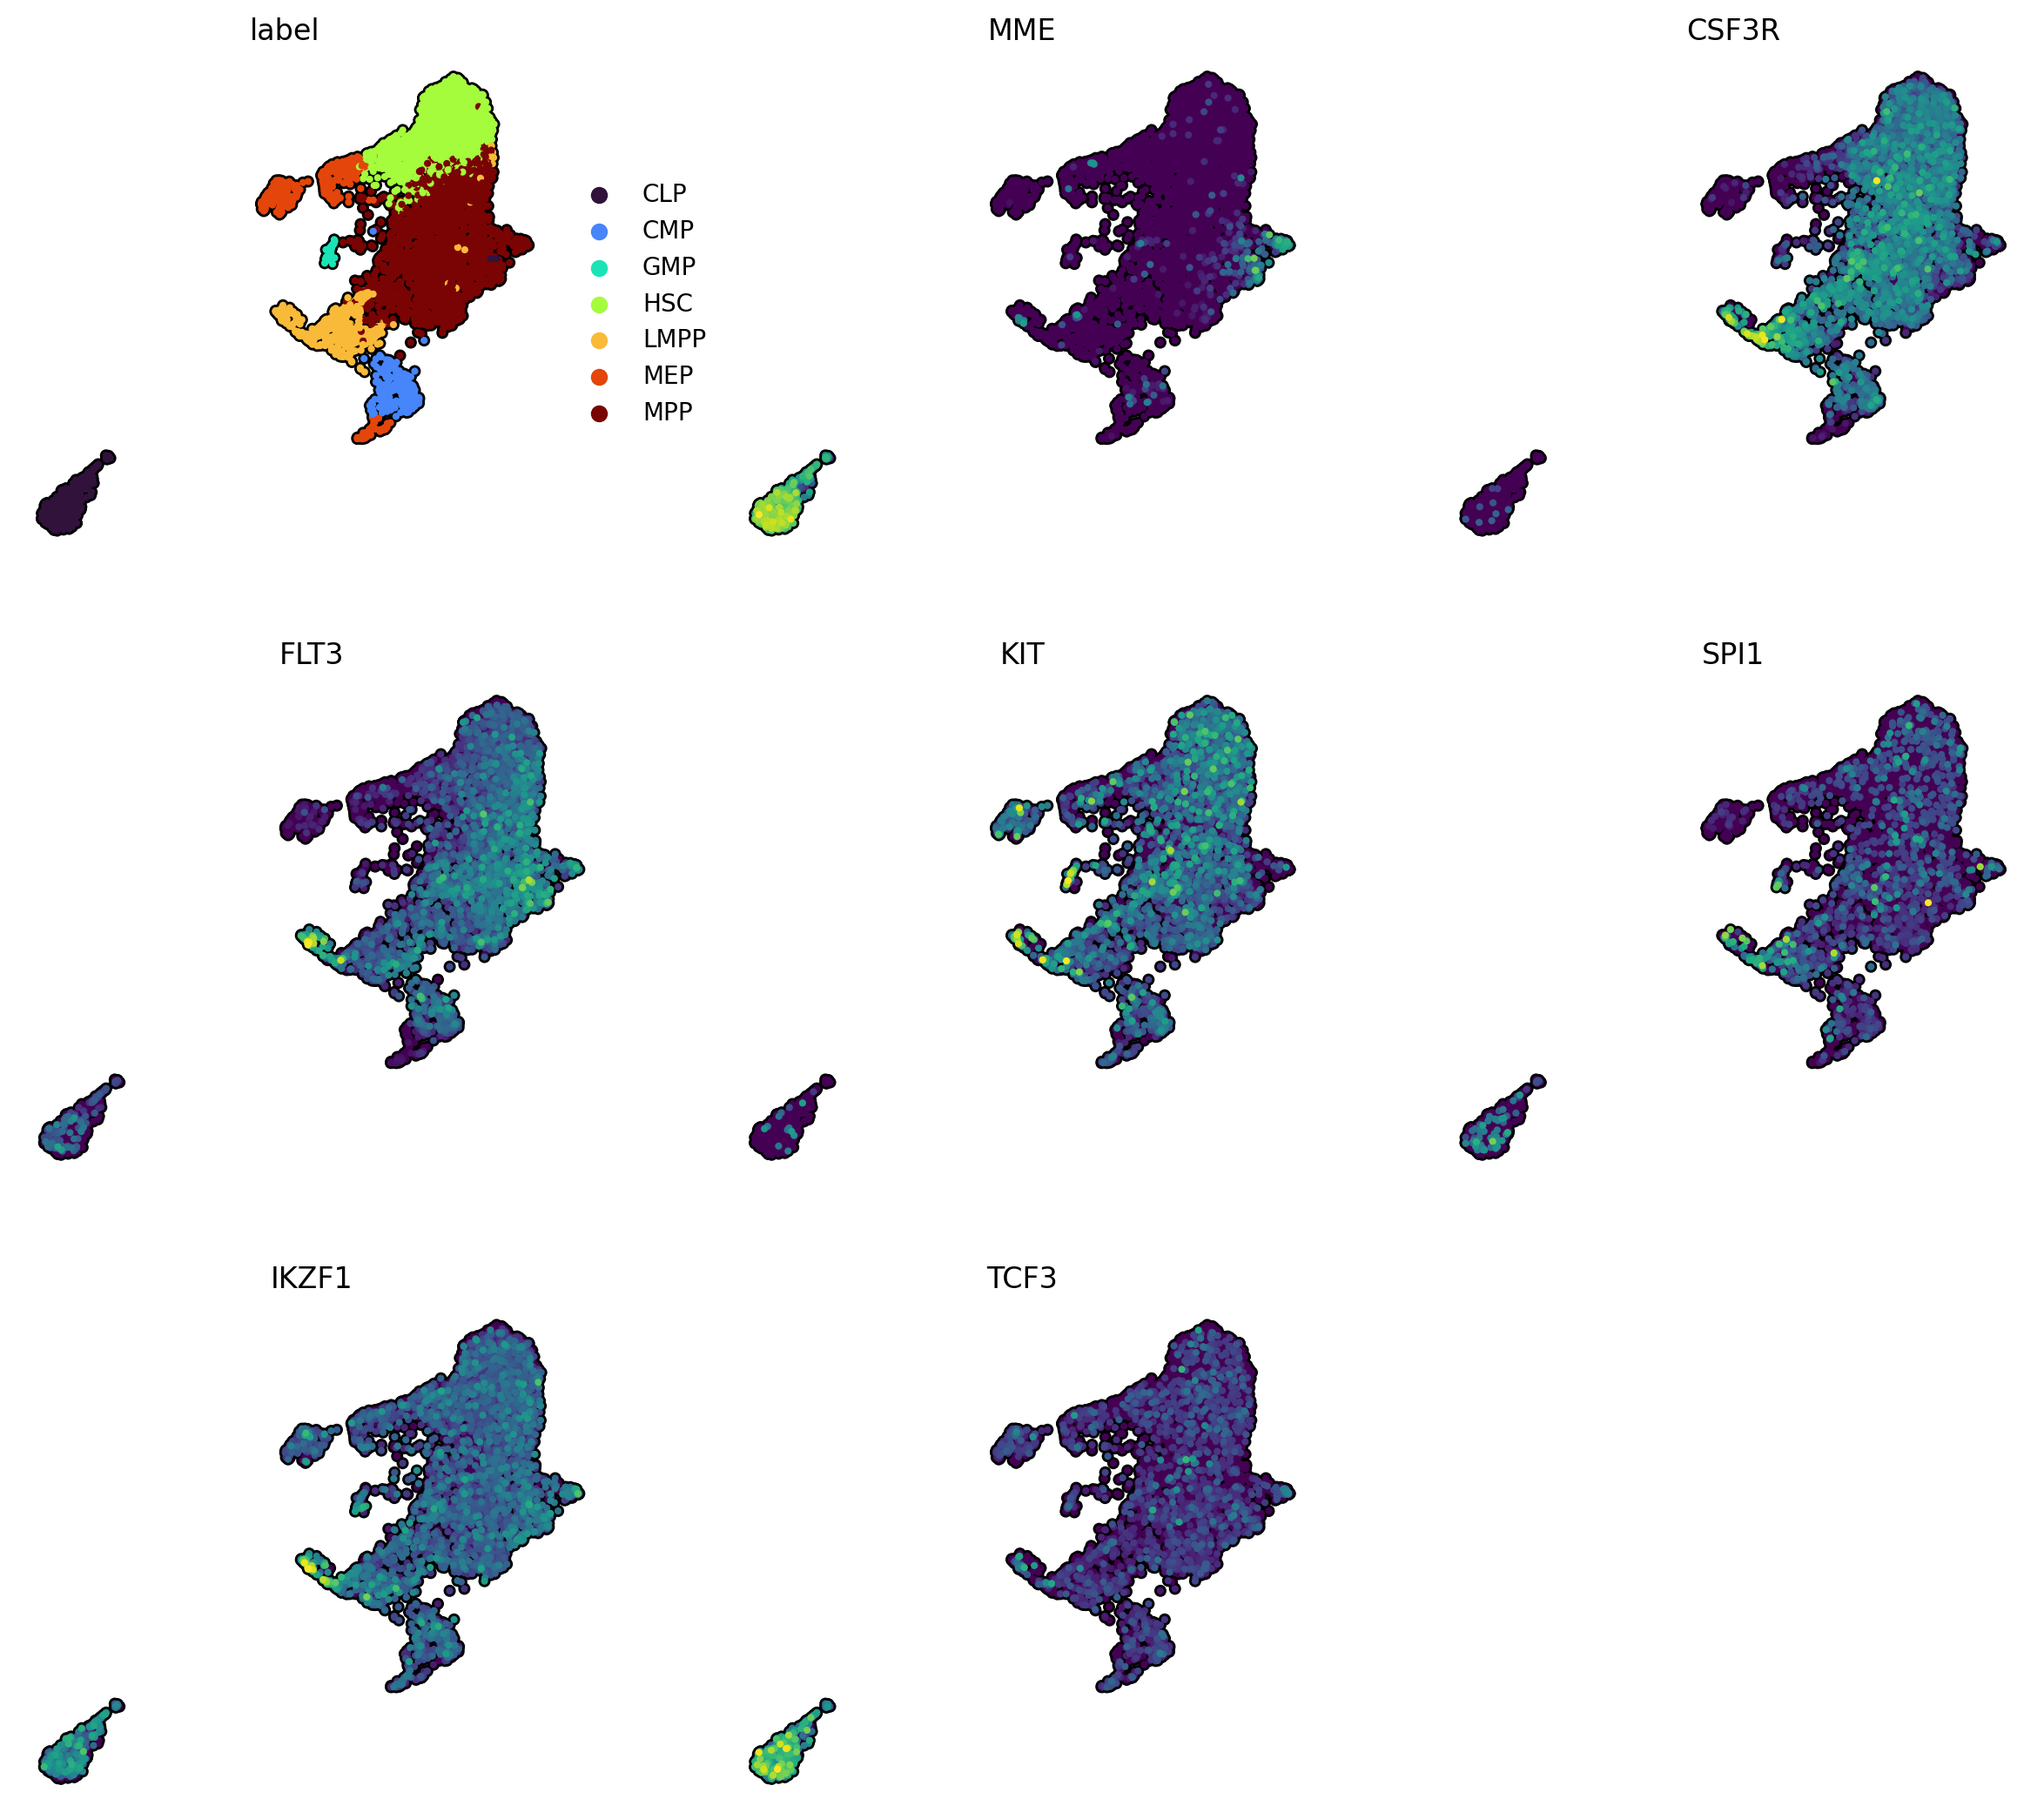

In [32]:
# LMPPs
standard_genes = [
    'MME', # + CD10
    'CSF3R', # +
    'FLT3',
    'KIT',
    'SPI1', # PU.1
    'IKZF1', # ikaros
    'TCF3', # E2A  
]

genes_to_plot = [g for g in standard_genes if g in adata.var_names]

sc.pl.umap(
    adata,
    color=['label'] + genes_to_plot,
    size=35,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    colorbar_loc=None,
    outline_color=('k', 'k'),
    frameon=False,
)

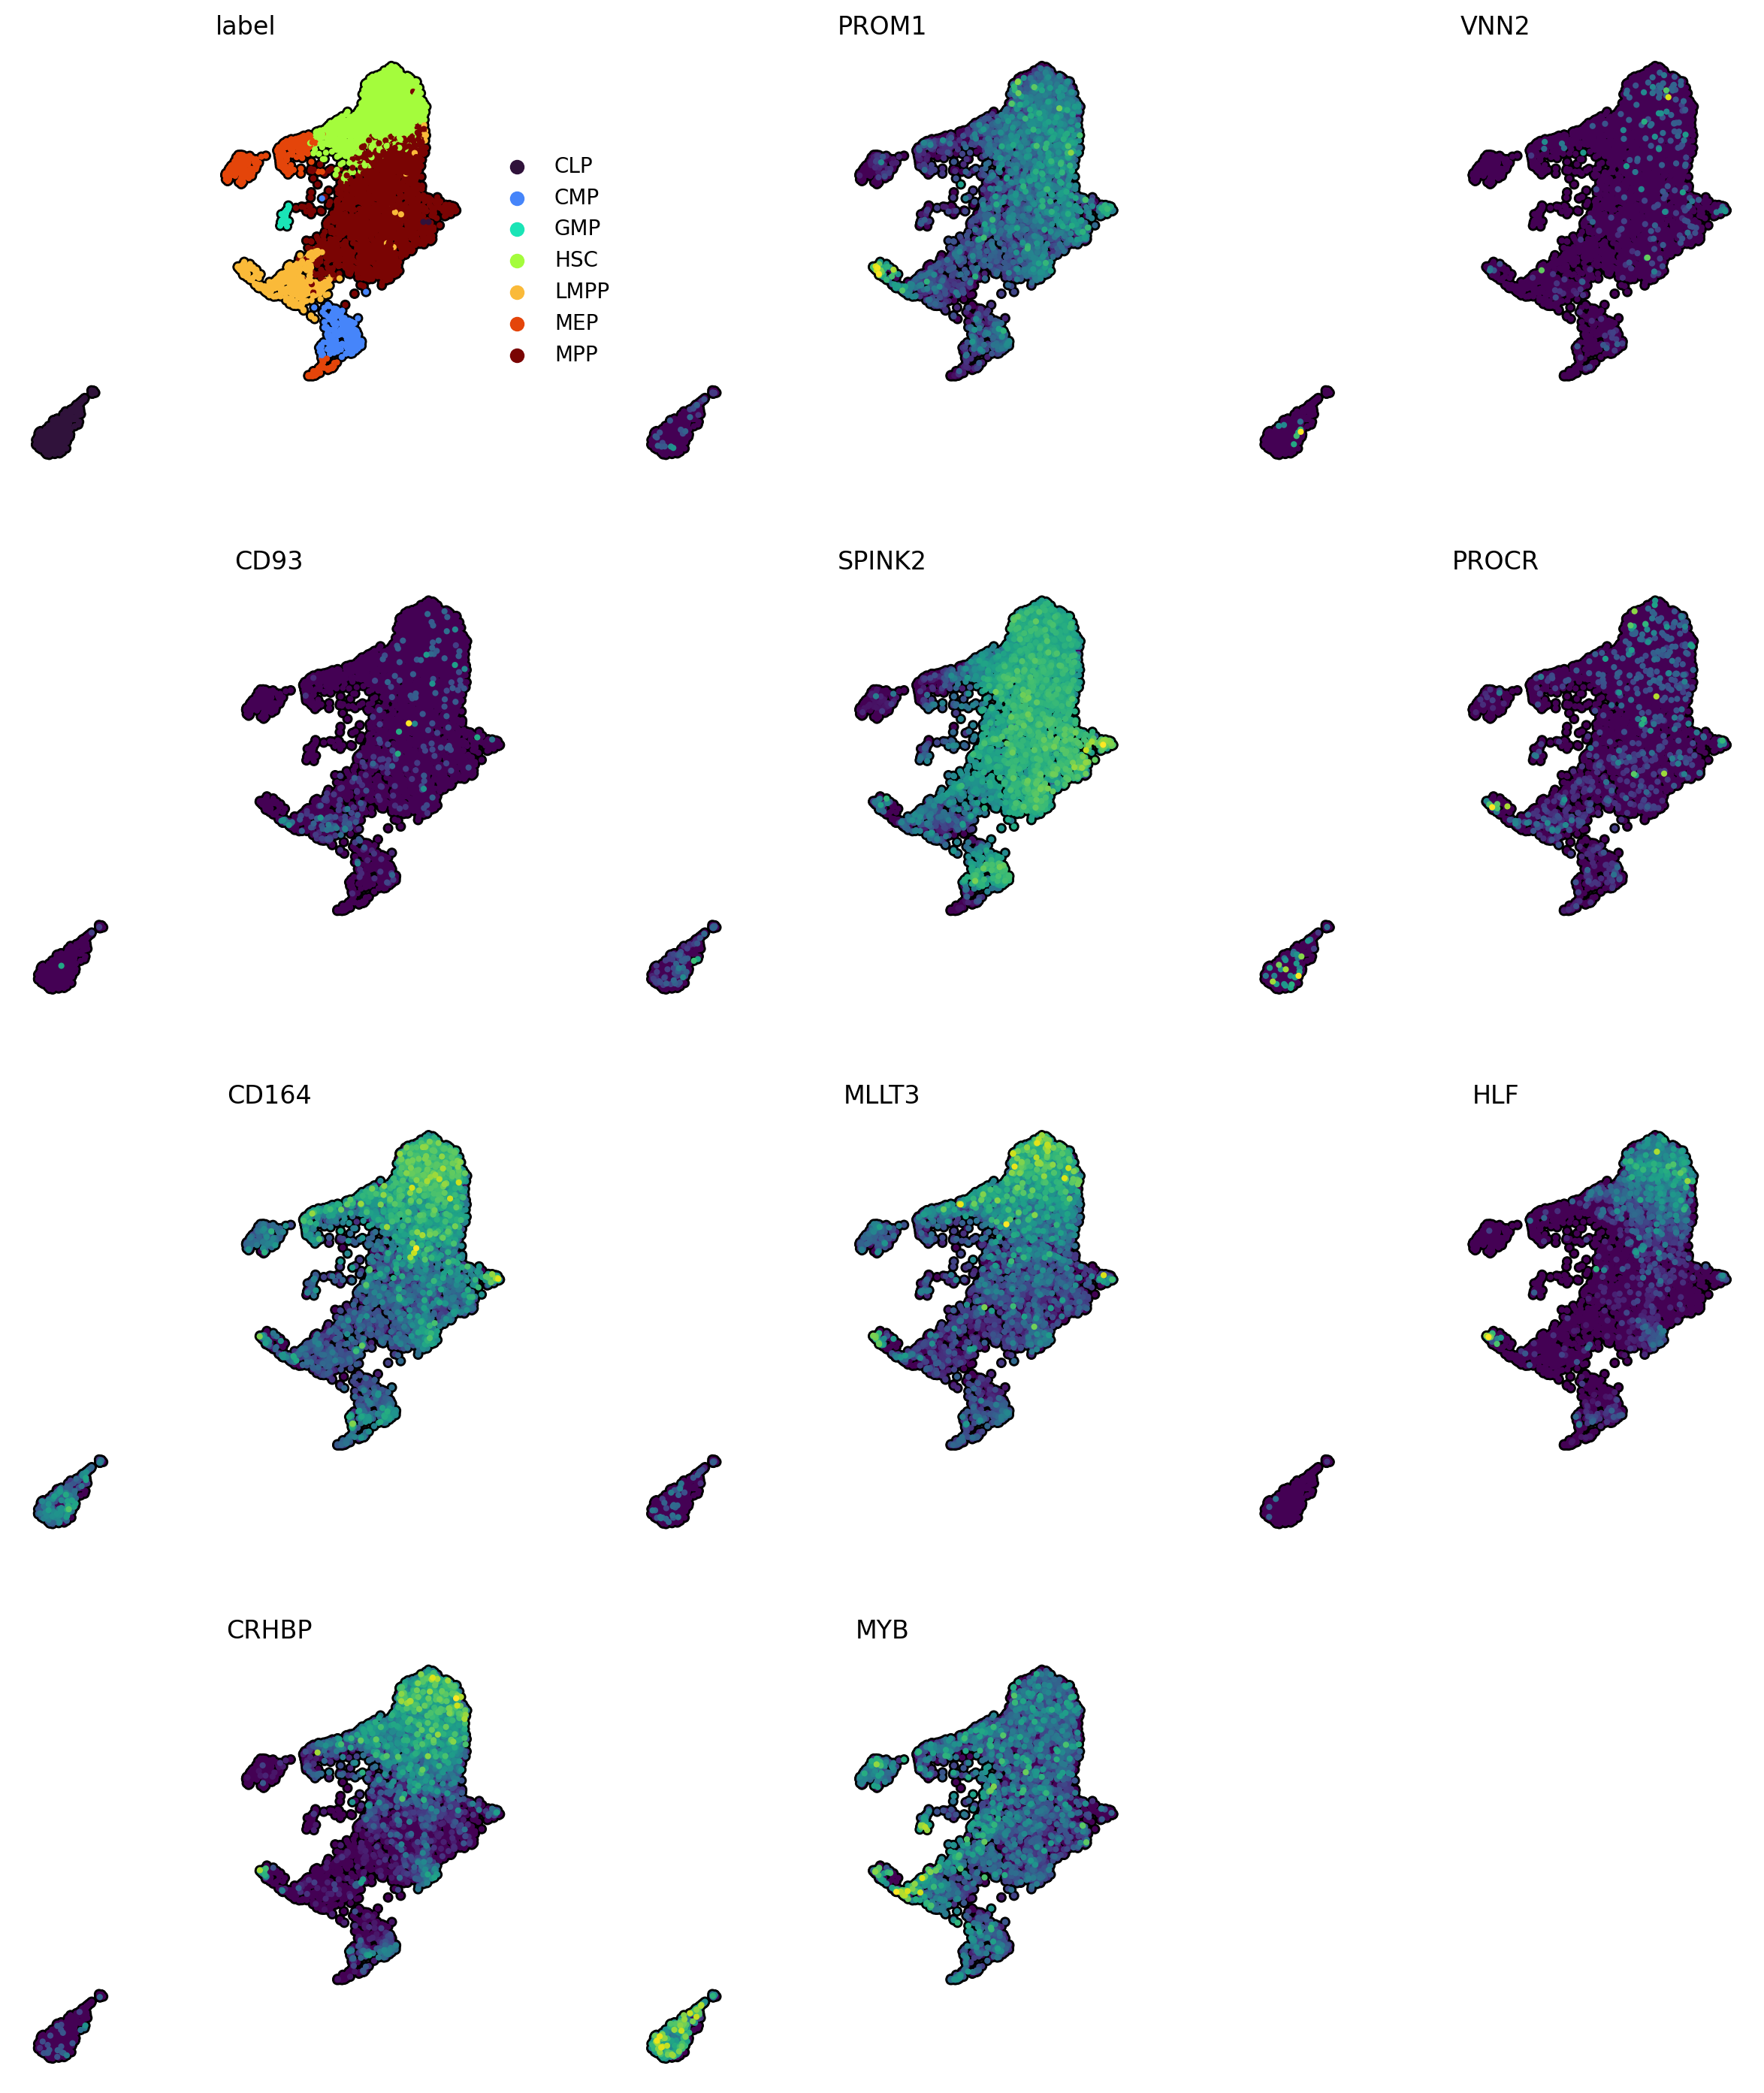

In [38]:
# HSC
standard_genes = [
    'PROM1', # CD133
    'VNN2',
    'CD93',
    'SPINK2',
    'PROCR',
    'CD164',
    'MLLT3',
    'HLF',
    'CRHBP',
    'MYB',
]

genes_to_plot = [g for g in standard_genes if g in adata.var_names]

sc.pl.umap(
    adata,
    color=['label'] + genes_to_plot,
    size=35,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    colorbar_loc=None,
    outline_color=('k', 'k'),
    frameon=False,
)

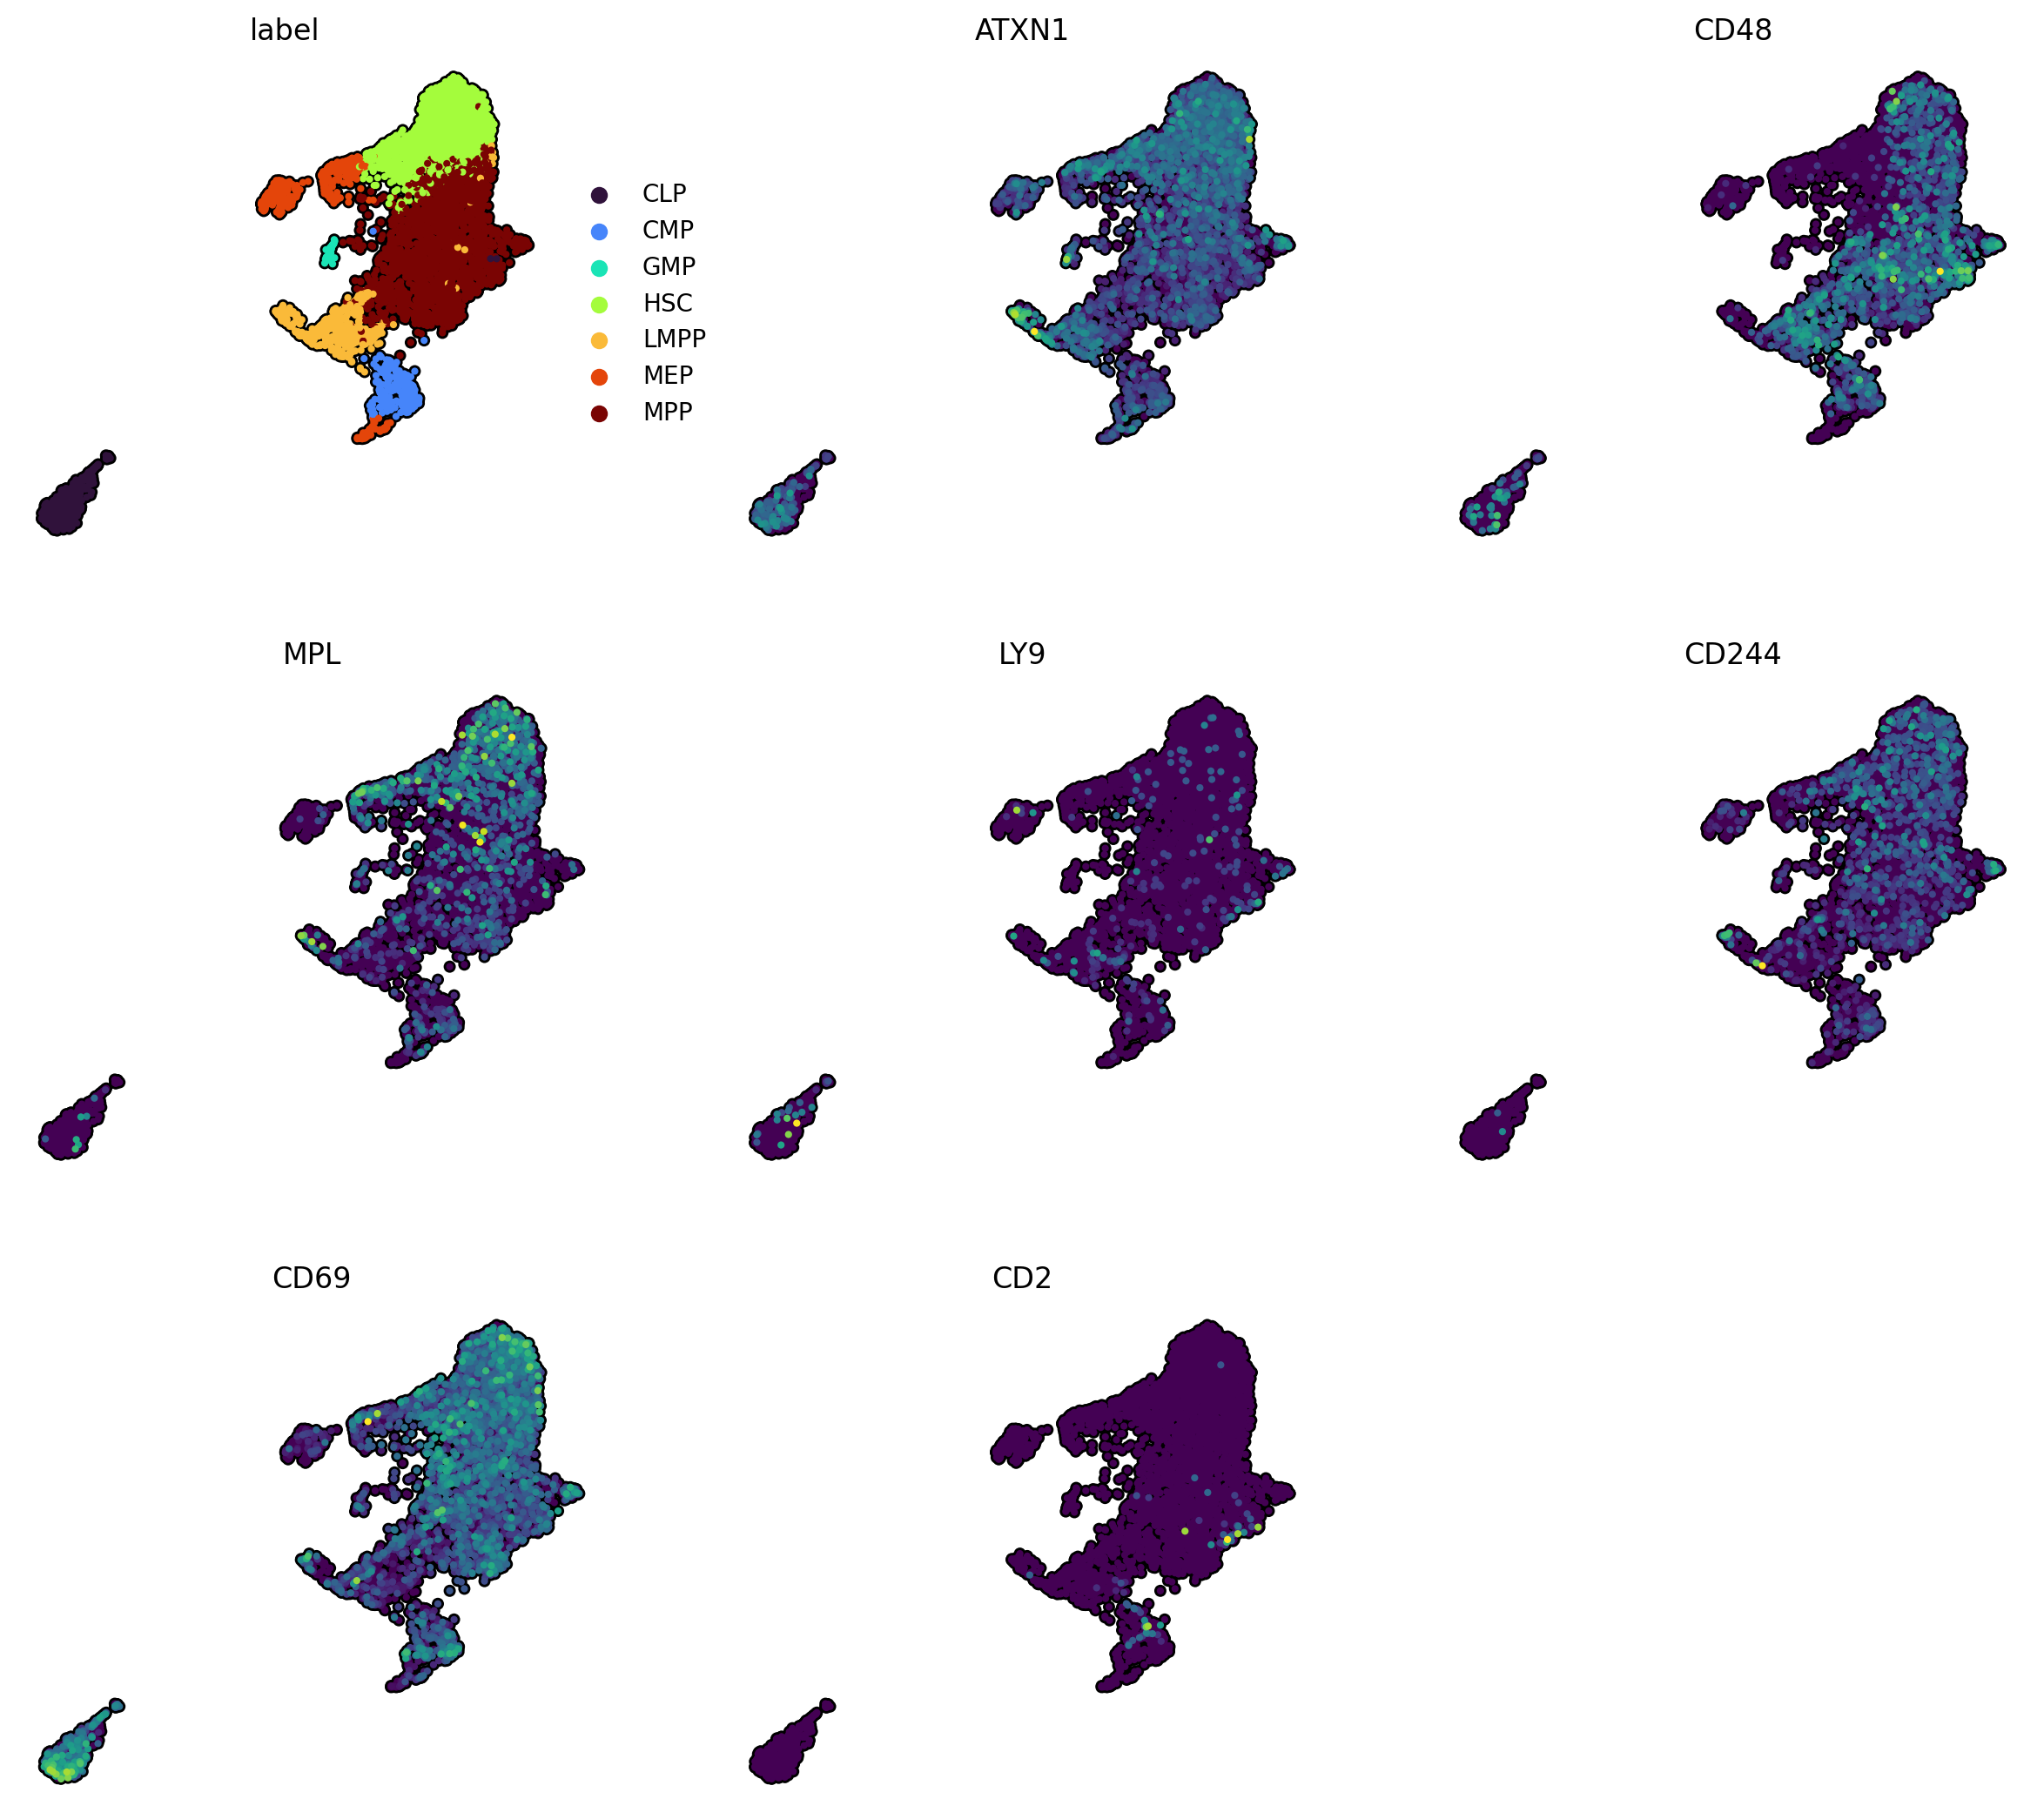

In [43]:
# MPPs
standard_genes = [
    'ATXN1', # Sca-1
    'SLAMF1', # CD150
    'CD48',
    'MPL',
    'LY9', # CD229
    'CD244',
    'CD69',
    'CLL1',
    'CD2',
]

genes_to_plot = [g for g in standard_genes if g in adata.var_names]

sc.pl.umap(
    adata,
    color=['label'] + genes_to_plot,
    size=35,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    colorbar_loc=None,
    outline_color=('k', 'k'),
    frameon=False,
)

## Good markers from DEGs per cluster

HSC -- CLEC3B CRHBP MYCT1 (CellMarker), HLF
MPP -- 
LMPP -- MPO ? 
CMP -- 
MEP -- HBD
GMP -- IL4, IL5RA
CLP -- RAG2